In [41]:
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [42]:
a = 1.0 * 10**(-9)
a_nm = a*10**9
N = 49
L = (N+1)*a
L_nm = (N+1)*a_nm
print("N=", N)
print("L=",L,"m")
print("L_nm=",L_nm,"nm")
print("a_nm=",a_nm,"nm")

N= 49
L= 5.0000000000000004e-08 m
L_nm= 50.0 nm
a_nm= 1.0 nm


In [43]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]
el_charge = physical_constants['elementary charge'][0]  
k_B = physical_constants['Boltzmann constant'][0] 
k_B_eV = k_B/eV_unit
h_bar_eV = h_bar/eV_unit

In [44]:
t = (h_bar**2) / (2*m_el*a**2)
t = t / eV_unit
print("t=",t)

t= 0.03809981988649954


In [45]:
sys = kwant.Builder()
lat = kwant.lattice.chain(a_nm)

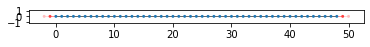

In [46]:
def onsite(site, x0, W0, U0):
    (x,) = site.pos
    if x >= x0 - W0/2 and x <= x0 + W0/2:
        return 2*t + U0
    else:
        return 2*t

for i in range(N):
    sys[lat(i)] = onsite
    
sys[lat.neighbors()] = -t

leadl = kwant.Builder(kwant.TranslationalSymmetry((-a_nm,)))
leadl[lat(0)] = 2*t
leadl[lat.neighbors()] = -t

leadr = leadl.reversed()

sys.attach_lead(leadl)
sys.attach_lead(leadr)

kwant.plot(sys);

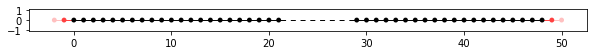

In [47]:
sysf = sys.finalized()
U0p = 0.5*t
x0p = 25
W0p = 6
kwant.plot(sysf, site_color=lambda \
           site:sysf.hamiltonian(site, site,params=dict(U0=U0p,x0=x0p,W0=W0p)), fig_size=(10,10), colorbar=False);

In [48]:
def calc_T(sysf, E, U0, x0, W0):
    smatrix = kwant.smatrix(sysf, E, params=dict(U0=U0,x0=x0,W0=W0))
    return smatrix.transmission(1, 0)

In [49]:
Emin = 0.0001
Emax = 2*U0p
NE = 100

U0p = 0.5*t
x0p = 25
W0p = 10

Etab = np.linspace(Emin, Emax, NE)
Ttab_p = np.zeros(NE)



Ttab_pp = np.zeros(NE)

for i in range(NE):
    Ttab_p[i] = calc_T(sysf, Etab[i], U0p, x0p, W0p)
    


U0p= 0.01904990994324977


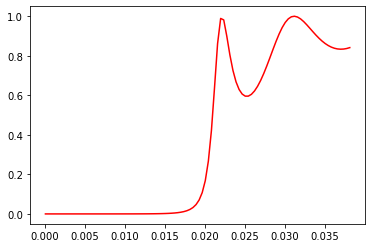

In [50]:
print("U0p=",U0p)
plt.plot(Etab, Ttab_p , "r");

In [24]:
from ipywidgets import interact


def plot_wf(i=1):
    wf = kwant.solvers.default.wave_function(sysf, Etab[i], params=dict(U0=U0p,x0=x0p,W0=W0p));
    
    print("E=",Etab[i])
    norm=np.sum(np.abs(wf(0)[:])**2)

    
    plt.subplot(1, 2, 1)
    plt.plot((np.abs(wf(0)[0]))**2/norm); 
    plt.xlabel('x')
    plt.ylabel('$|\Psi|^2$')
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.plot(Etab,Ttab_p)
    plt.xlabel('E')
    plt.ylabel('T')
    plt.grid()
    plt.axvline(x = Etab[i], color = 'tab:red', label = 'axvline - full height')
    plt.tight_layout()
    plt.show()
       
    
interact(plot_wf, i=(0,NE));

interactive(children=(IntSlider(value=1, description='i'), Output()), _dom_classes=('widget-interact',))

In [25]:
T = 293
bet = 1/(k_B_eV*T)
C = el_charge*m_ef*k_B_eV*T/( 2*np.pi**2*h_bar_eV**3 )*6.242*10**14

def fs_funk(ene, mul, mur, bet):
    return np.log( ( np.exp(-bet*(ene-mul))+1 )/( np.exp(-bet*(ene-mur))+1 ) )

NameError: name 'm_ef' is not defined